In [1]:
#Third party imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

In [2]:
#Load csv files into dataframes

df1 = pd.read_csv("mexico-real-estate-1.csv")
df2 = pd.read_csv("mexico-real-estate-2.csv")
df3 = pd.read_csv("mexico-real-estate-3.csv")

In [3]:
# Get summary information for df1 (Data types, memory, non-null counts)
# Get shape for df1 (Rows, Columns)
# Get head for df1 (first 5 rows)

print(df1.info()); print( df1.shape)
df1.head()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  700 non-null    str    
 1   state          700 non-null    str    
 2   lat            583 non-null    float64
 3   lon            583 non-null    float64
 4   area_m2        700 non-null    float64
 5   price_usd      700 non-null    str    
dtypes: float64(3), str(3)
memory usage: 32.9 KB
None
(700, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,"$67,965.56"
1,house,Nuevo León,25.688436,-100.198807,186.0,"$63,223.78"
2,apartment,Guerrero,16.767704,-99.764383,82.0,"$84,298.37"
3,apartment,Guerrero,16.829782,-99.911012,150.0,"$94,308.80"
4,house,Veracruz de Ignacio de la Llave,NaN,NaN,175.0,"$94,835.67"


In [4]:
# Get summary information for df2 (data types, memory, non-null counts)
# Get shape for df2 (Rows, Columns)
# Get head for df2 (First 5 rows)

print(df2.info()); print(df2.shape)
df2.head()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  700 non-null    str    
 1   state          700 non-null    str    
 2   lat            571 non-null    float64
 3   lon            571 non-null    float64
 4   area_m2        700 non-null    float64
 5   price_mxn      700 non-null    float64
dtypes: float64(4), str(2)
memory usage: 32.9 KB
None
(700, 6)


,property_type,state,lat,lon,area_m2,price_mxn
0,apartment,Nuevo León,25.721081,-100.345581,72.0,1300000.0
1,apartment,Puebla,NaN,NaN,190.0,2500000.0
2,house,Morelos,23.634501,-102.552788,360.0,5300000.0
3,house,Morelos,NaN,NaN,76.0,820000.0
4,house,Puebla,NaN,NaN,200.0,1100000.0


In [5]:
# Get summary information for df3 (data types, memory, non-null count)
# Get shape of df3 (Rows, Columns)
# Get head for df3 (First 5 rows)

print(df3.info()); print(df3.shape)
df3.head()

<class 'pandas.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   property_type            700 non-null    str    
 1   place_with_parent_names  700 non-null    str    
 2   lat-lon                  582 non-null    str    
 3   area_m2                  700 non-null    float64
 4   price_usd                700 non-null    float64
dtypes: float64(2), str(3)
memory usage: 27.5 KB
None
(700, 5)


,property_type,place_with_parent_names,lat-lon,area_m2,price_usd
0,apartment,|México|Distrito Federal|Gustavo A. Madero|Acu...,"19.52589,-99.151703",71.0,48550.59
1,house,|México|Estado de México|Toluca|Metepec|,"19.2640539,-99.5727534",233.0,168636.73
2,house,|México|Estado de México|Toluca|Toluca de Lerd...,"19.268629,-99.671722",300.0,86932.69
3,house,|México|Morelos|Temixco|Burgos Bugambilias|,NaN,275.0,263432.41
4,apartment,|México|Veracruz de Ignacio de la Llave|Veracruz|,"19.511938,-96.871956",84.0,68508.67


In [6]:
# Remove `NaN` values from the df1 dataset
df1.dropna(inplace=True)

In [7]:
# Remove dollar sign and comma from `price usd` 
# Convert the values from string to float type

df1["price_usd"] = (df1["price_usd"]
                    .str.replace("$", "", regex=False)
                    .str.replace(",", "")
                    .astype(float)
                    )

In [8]:
#Confirm that the new dataframe has no null values and the right data types

print(df1.info()); print(df1.shape)
df1.head()

<class 'pandas.DataFrame'>
Index: 583 entries, 0 to 699
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  583 non-null    str    
 1   state          583 non-null    str    
 2   lat            583 non-null    float64
 3   lon            583 non-null    float64
 4   area_m2        583 non-null    float64
 5   price_usd      583 non-null    float64
dtypes: float64(4), str(2)
memory usage: 31.9 KB
None
(583, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
5,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [9]:
# Drop `NaN` values from df2
df2.dropna(inplace=True)

In [10]:
# Create `price_usd` column by converting the currency from pesos to USD
# Round result to 2 decimal places
# One dollar is 19 mexican pesos

df2["price_usd"] = (df2["price_mxn"] / 19).round(2)

In [11]:
# Drop `price_mxn` column

df2.drop(columns=["price_mxn"], inplace=True)

In [12]:
# Confirm that the new dataframe has the right columns and no null values

df2.head()

,property_type,state,lat,lon,area_m2,price_usd
0,apartment,Nuevo León,25.721081,-100.345581,72.0,68421.05
2,house,Morelos,23.634501,-102.552788,360.0,278947.37
6,apartment,Estado de México,19.272040,-99.572013,85.0,65789.47
7,house,San Luis Potosí,22.138882,-100.996510,158.0,111578.95
8,apartment,Distrito Federal,19.394558,-99.129707,65.0,39904.74


In [13]:
df3.head()

,property_type,place_with_parent_names,lat-lon,area_m2,price_usd
0,apartment,|México|Distrito Federal|Gustavo A. Madero|Acu...,"19.52589,-99.151703",71.0,48550.59
1,house,|México|Estado de México|Toluca|Metepec|,"19.2640539,-99.5727534",233.0,168636.73
2,house,|México|Estado de México|Toluca|Toluca de Lerd...,"19.268629,-99.671722",300.0,86932.69
3,house,|México|Morelos|Temixco|Burgos Bugambilias|,NaN,275.0,263432.41
4,apartment,|México|Veracruz de Ignacio de la Llave|Veracruz|,"19.511938,-96.871956",84.0,68508.67


In [14]:
# Split the `"lat-lon"` column into "lat" and "lon"
df3[["lat", "lon"]] = (
    df3["lat-lon"]
    .str.split(",", expand=True)
    .astype(float))

In [15]:
# Create a state column from `place_with_parent_names` by splitting it

df3["state"] = (
    df3["place_with_parent_names"]
    .str.split("|", expand=True)[2]
)

In [16]:
# Drop `lat-lon` and `place_with_parent_names` columns

df3.drop(columns=["lat-lon", "place_with_parent_names"], inplace=True)

In [17]:
# Drop `NaN` values
df3.dropna(inplace=True)

In [18]:
# Confirm dataframe has the right column names and no null values
df3.head()

,property_type,area_m2,price_usd,lat,lon,state
0,apartment,71.0,48550.59,19.525890,-99.151703,Distrito Federal
1,house,233.0,168636.73,19.264054,-99.572753,Estado de México
2,house,300.0,86932.69,19.268629,-99.671722,Estado de México
4,apartment,84.0,68508.67,19.511938,-96.871956,Veracruz de Ignacio de la Llave
5,house,175.0,102763.00,20.689157,-103.366728,Jalisco


In [19]:
# Concatenate the three cleaned dataframes

df = pd.concat([df1, df2, df3])
print(df.info()); print(df.shape)
df.head()

<class 'pandas.DataFrame'>
Index: 1736 entries, 0 to 699
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  1736 non-null   str    
 1   state          1736 non-null   str    
 2   lat            1736 non-null   float64
 3   lon            1736 non-null   float64
 4   area_m2        1736 non-null   float64
 5   price_usd      1736 non-null   float64
dtypes: float64(4), str(2)
memory usage: 94.9 KB
None
(1736, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80
5,house,Yucatán,21.052583,-89.538639,205.0,105191.37


In [20]:
# Save cleaned data in a .csv file

df.to_csv("mexico_real_estate_clean.csv", index=False)

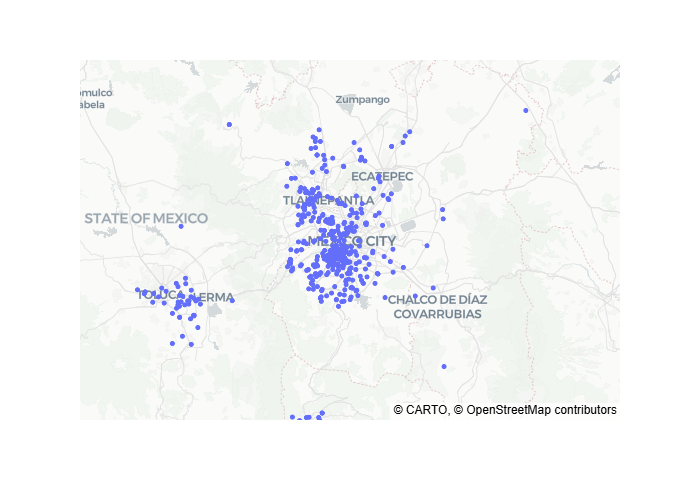

In [21]:
# Visualize locations as scatter plot on top of a map

fig = px.scatter_map (
    df,
    lat="lat",
    lon="lon",
    center={"lat": 19.43, "lon": -99.13},
    hover_data=["price_usd"]
)

fig.update_layout(map_style="carto-positron")

fig.write_image("mapbox.png")
fig.show(renderer="png")

In [22]:
# Use value counts to determine the 10 most prevalent states in the data

top_10 = df["state"].value_counts().head(10)
top_10

state
Distrito Federal                   303
Estado de México                   179
Yucatán                            171
Morelos                            160
Querétaro                          128
Veracruz de Ignacio de la Llave    117
Puebla                              95
Nuevo León                          83
Jalisco                             60
Chiapas                             55
Name: count, dtype: int64

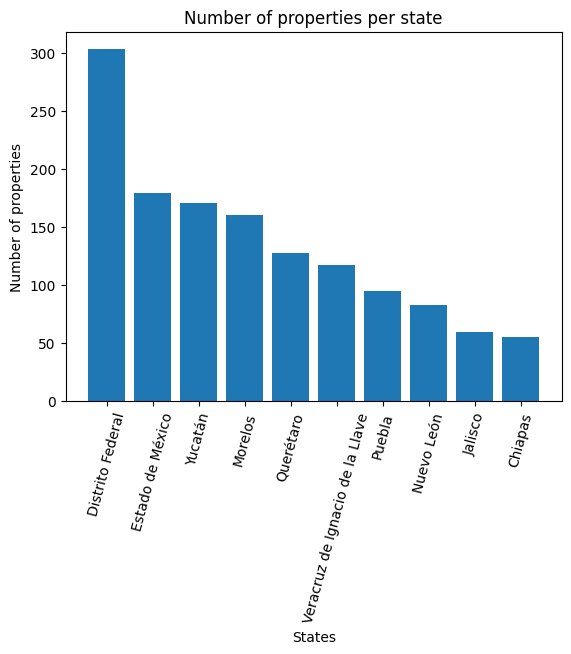

In [23]:
# Plot a bar chart of the states and the number of properties per state

plt.bar(x=top_10.index, height=top_10.values)

# Label x and y axis
plt.xlabel("States")
plt.ylabel("Number of properties")

# Provide title
plt.title("Number of properties per state")

plt.xticks(rotation=75);

In [24]:
# Use describe to summary "area_m2" and "price_usd"

df[["area_m2", "price_usd"]].describe()

,area_m2,price_usd
count,1736.000000,1736.000000
mean,170.261521,115331.980766
std,80.594539,65426.173873
min,60.000000,33157.890000
25%,101.750000,65789.470000
50%,156.000000,99262.130000
75%,220.000000,150846.665000
max,385.000000,326733.660000


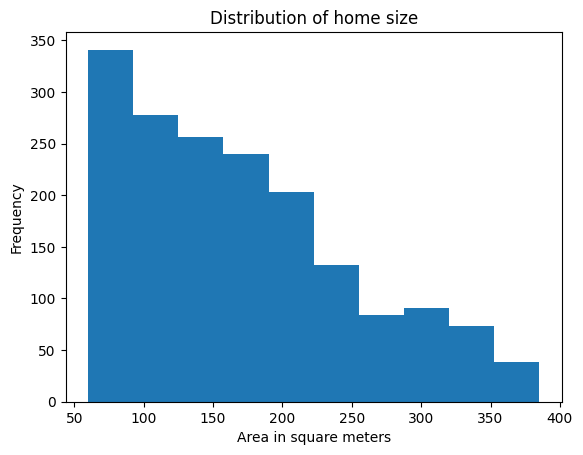

In [25]:
# Use Matplotlib to create histogram to visualize distribution of "area_m2"

plt.hist(
    df["area_m2"]
)

# Add x-axis label
plt.xlabel("Area in square meters")

#Add y-axis label
plt.ylabel("Frequency")

# Add title
plt.title("Distribution of home size");

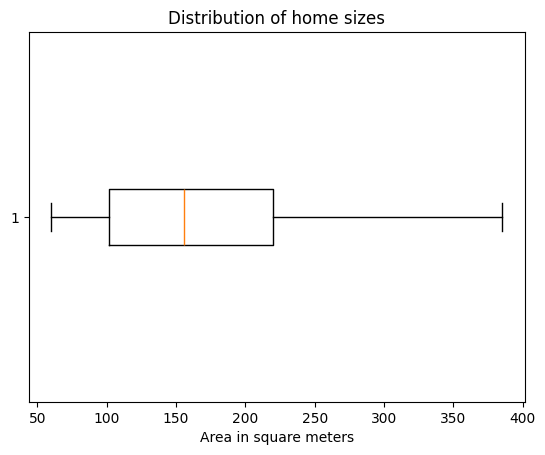

In [26]:
# Use Matplotlib to create a horizontal boxplot of "area_m2"4.2.0

plt.boxplot(df["area_m2"], vert=False)

# Add x-axis label
plt.xlabel("Area in square meters")

# Add title
plt.title("Distribution of home sizes");

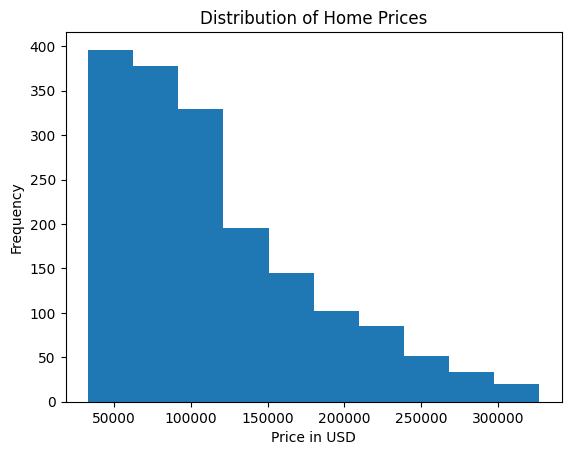

In [27]:
# Use Matplotlib to create a histogram of "price_usd"

plt.hist(df["price_usd"])

# Add x-axis label
plt.xlabel("Price in USD")

# Add y-axis label
plt.ylabel("Frequency")

# Add title
plt.title("Distribution of Home Prices");

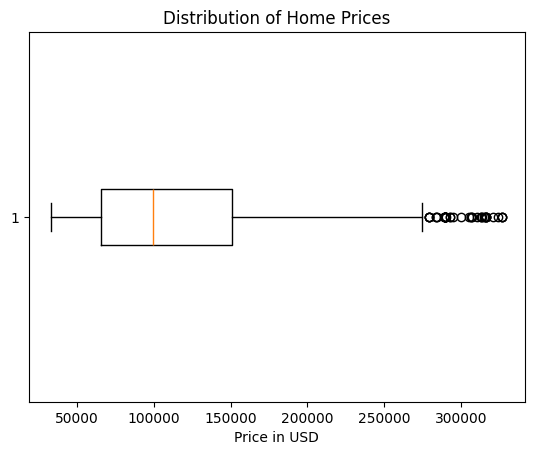

In [28]:
# Use Matplotlib to create a horizontal boxplot of "price_usd"4.2.0

plt.boxplot(df["price_usd"], vert=False)

# Add x-axis label
plt.xlabel("Price in USD")

plt.title("Distribution of Home Prices");

In [31]:
# Group by state to find the mean price of houses per state
mean_price_by_state = (
    df.groupby("state")
    ["price_usd"].mean()
    .sort_values(ascending=False)
)

mean_price_by_state.head()

state
Querétaro           133955.913281
Guanajuato          133277.965833
Nuevo León          129221.985663
Distrito Federal    128347.267426
Quintana Roo        128065.416053
Name: price_usd, dtype: float64

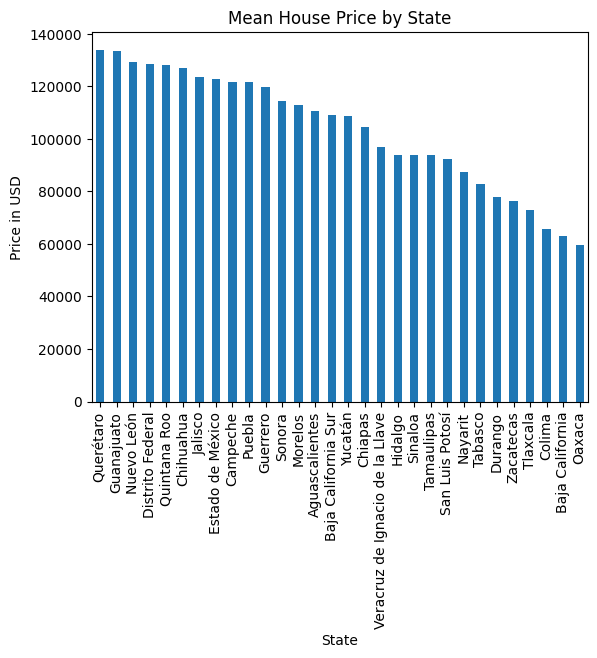

In [32]:
# Create a bar chart from mean price by state

mean_price_by_state.plot(
    kind="bar",
    xlabel="State",
    ylabel="Price in USD",
    title="Mean House Price by State"
);

In [33]:
# Create a "price_per_m2" column

df["price_per_m2"] = df["price_usd"] / df["area_m2"]
df.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
0,house,Estado de México,19.560181,-99.233528,150.0,67965.56,453.103733
1,house,Nuevo León,25.688436,-100.198807,186.0,63223.78,339.912796
2,apartment,Guerrero,16.767704,-99.764383,82.0,84298.37,1028.028902
3,apartment,Guerrero,16.829782,-99.911012,150.0,94308.80,628.725333
5,house,Yucatán,21.052583,-89.538639,205.0,105191.37,513.128634


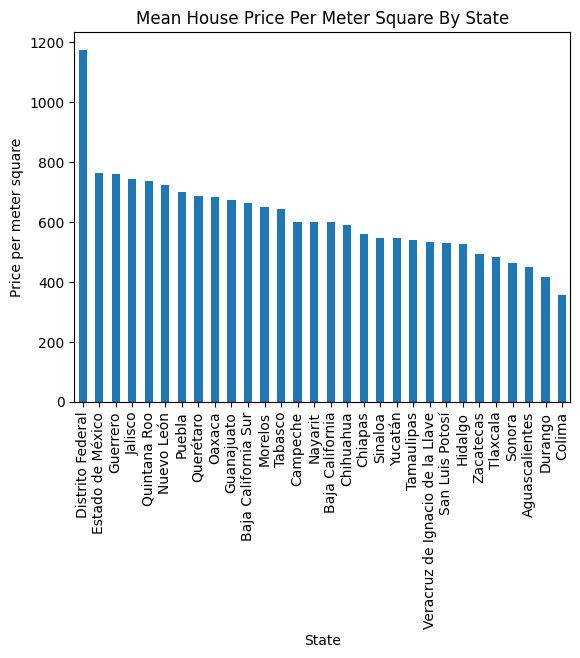

In [34]:
# Get average price_per_m2 for each state
# Visualize price_per_m2 per state

(
    df.groupby("state")
    ["price_per_m2"].mean()
    .sort_values(ascending=False)
    .plot(
        kind="bar",
        xlabel="State",
        ylabel="Price per meter square",
        title="Mean House Price Per Meter Square By State"
    )
);

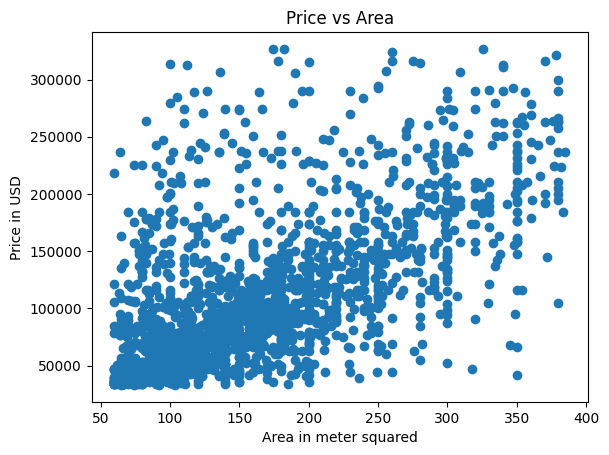

In [35]:
# Create scatter plot of "price_usd" vs "area_m2"

plt.scatter(
    x=df["area_m2"],
    y=df["price_usd"]
)

# Add x-axis label
plt.xlabel("Area in meter squared")

# Add y-axis label
plt.ylabel("Price in USD")

# Add title
plt.title("Price vs Area");

In [36]:
# Calculate correlation of "price_usd" and "area_m2"
p_correlation = df["area_m2"].corr(df["price_usd"])
print(f"Correlation of 'area_m2' and 'price_usd' is {p_correlation}")

Correlation of 'area_m2' and 'price_usd' is 0.585518245323206


In [37]:
# Create df_morelos data frame by subsetting `df`

df_morelos = df[df["state"] == "Morelos"]
df_morelos.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
9,house,Morelos,18.812605,-98.954826,281.0,151509.56,539.179929
12,house,Morelos,18.804197,-98.932816,117.0,63223.78,540.374188
21,house,Morelos,18.855343,-99.241142,73.0,36775.16,503.769315
60,house,Morelos,18.804197,-98.932816,130.0,65858.10,506.600769
66,house,Morelos,18.960244,-99.212962,305.0,227351.46,745.414623


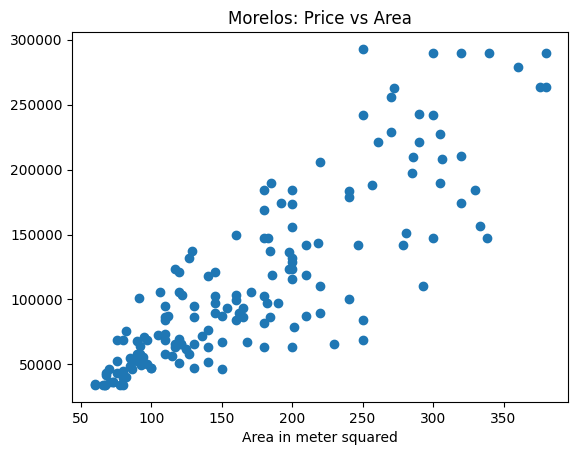

In [40]:
# Create scatter plot showing price vs area in df_morelos

plt.scatter(x=df_morelos["area_m2"], y=df_morelos["price_usd"])

# Label x-axis
plt.xlabel("Area in meter squared")

# Label y-axis("Price in USD")

# Add title
plt.title("Morelos: Price vs Area");

In [41]:
# Check Correlation between price and size in Morelos

morelos_correlation = df_morelos["area_m2"].corr(df_morelos["price_usd"])
print(f"Correlation of area and price in Morelos is {morelos_correlation}")

Correlation of area and price in Morelos is 0.8498077608713712


In [42]:
# Create df_mexico dataframe by subsetting df

df_mexico = df[df["state"] == "Distrito Federal"]
df_mexico.head()

,property_type,state,lat,lon,area_m2,price_usd,price_per_m2
17,apartment,Distrito Federal,19.390748,-99.158695,127.0,131716.20,1037.135433
19,house,Distrito Federal,19.337652,-99.223327,297.0,264390.77,890.204613
23,apartment,Distrito Federal,19.403334,-99.157755,129.0,131716.20,1021.055814
24,apartment,Distrito Federal,19.428152,-99.106194,68.0,67175.26,987.871471
29,apartment,Distrito Federal,19.430141,-99.172536,97.0,104846.10,1080.887629


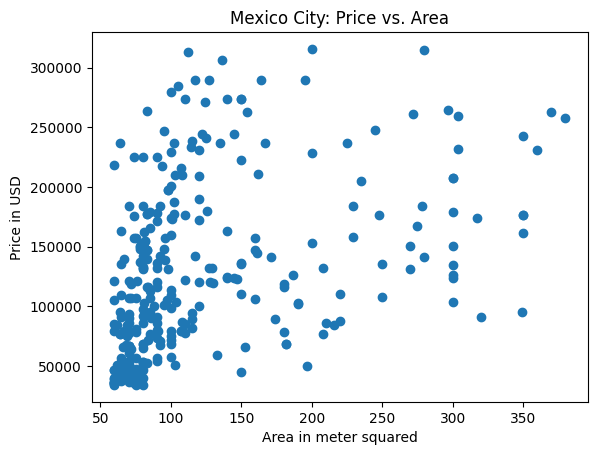

In [43]:
# Create scatter plot of "area_m2" and "price_usd" for df_mexico

plt.scatter(x=df_mexico["area_m2"], y=df_mexico["price_usd"])

# Add x-axis label
plt.xlabel("Area in meter squared")

# Add y-axis label
plt.ylabel("Price in USD")

# Add title
plt.title("Mexico City: Price vs. Area");

In [44]:
# Calculate correlation between price and house in Mexico City

mexico_correlation = df_mexico["area_m2"].corr(df_mexico["price_usd"])
print(f"Correlation between area and price in Mexico city is {mexico_correlation}.")

Correlation between area and price in Mexico city is 0.41070392130717864.
